In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [66]:
df = pd.read_csv("synthetic_asthma_1200.csv")

In [67]:
df.head()

,patient_id,age_years,sex,height_cm,weight_kg,bmi,smoking_status,pack_years,secondhand_smoke,physical_activity_days_week,...,montelukast_use,medication_adherence_pct,inhaler_technique,FEV1_percent_predicted,FEV1_FVC_ratio,PEF_percent_predicted,blood_eosinophils_percent,asthma_diagnosis,asthma_severity,asthma_control_status
0,ASTH_0001,17,Female,164.9,63.0,23.2,Former,13.8,0,3.1,...,0,NaN,Not applicable,88.6,0.73,120.9,4.2,No asthma,NaN,Not applicable
1,ASTH_0002,13,Female,156.3,73.4,30.0,Current,11.4,0,3.8,...,0,66.9,Suboptimal,86.6,0.71,86.3,3.0,Asthma,Severe persistent,Uncontrolled
2,ASTH_0003,42,Male,172.5,61.9,20.8,Never,0.0,0,2.6,...,0,NaN,Not applicable,72.5,0.64,98.4,2.6,No asthma,NaN,Not applicable
3,ASTH_0004,84,Male,160.8,67.8,26.2,Current,8.6,0,4.0,...,0,NaN,Not applicable,35.0,0.80,87.6,3.3,No asthma,NaN,Not applicable
4,ASTH_0005,34,Female,166.0,62.2,22.6,Never,0.0,0,5.1,...,0,NaN,Not applicable,98.0,0.80,121.4,0.0,No asthma,NaN,Not applicable


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1200 non-null   object 
 1   age_years                       1200 non-null   int64  
 2   sex                             1200 non-null   object 
 3   height_cm                       1200 non-null   float64
 4   weight_kg                       1200 non-null   float64
 5   bmi                             1200 non-null   float64
 6   smoking_status                  1200 non-null   object 
 7   pack_years                      1200 non-null   float64
 8   secondhand_smoke                1200 non-null   int64  
 9   physical_activity_days_week     1200 non-null   float64
 10  urban_residence                 1200 non-null   int64  
 11  occupational_airway_exposure    1200 non-null   int64  
 12  indoor_mold_exposure            12

In [32]:
print("=" * 80)
print("بررسی اولیه داده‌ها")
print("=" * 80)
print(f"تعداد کل ردیف‌ها: {len(df)}")
print(f"تعداد کل ستون‌ها: {len(df.columns)}")
print(f"\nستون‌های موجود:\n{df.columns.tolist()}")

بررسی اولیه داده‌ها
تعداد کل ردیف‌ها: 1200
تعداد کل ستون‌ها: 47

ستون‌های موجود:
['patient_id', 'age_years', 'sex', 'height_cm', 'weight_kg', 'bmi', 'smoking_status', 'pack_years', 'secondhand_smoke', 'physical_activity_days_week', 'urban_residence', 'occupational_airway_exposure', 'indoor_mold_exposure', 'pet_exposure', 'annual_mean_pollution_index', 'family_history_asthma', 'atopy_or_positive_allergy_test', 'allergic_rhinitis', 'eczema', 'food_allergy', 'childhood_recurrent_wheeze', 'GERD', 'chronic_rhinosinusitis', 'obstructive_sleep_apnea', 'COPD', 'aspirin_sensitivity', 'hypertension', 'beta_blocker_use', 'wheeze_days_4weeks', 'night_awakenings_4weeks', 'activity_limitation_0to3', 'SABA_use_days_4weeks', 'exacerbations_last_12mo', 'oral_steroid_courses_last_12mo', 'rescue_inhaler_prescribed', 'ICS_dose', 'LABA_use', 'montelukast_use', 'medication_adherence_pct', 'inhaler_technique', 'FEV1_percent_predicted', 'FEV1_FVC_ratio', 'PEF_percent_predicted', 'blood_eosinophils_percent', '

In [33]:
# بررسی توزیع متغیرهای هدف
print("\n" + "=" * 80)
print("توزیع متغیرهای هدف")
print("=" * 80)
print("\n1. توزیع تشخیص آسم (asthma_diagnosis):")
print(df['asthma_diagnosis'].value_counts())


توزیع متغیرهای هدف

1. توزیع تشخیص آسم (asthma_diagnosis):
asthma_diagnosis
No asthma    803
Asthma       397
Name: count, dtype: int64


In [34]:
print("\n2. توزیع شدت آسم (asthma_severity) - فقط برای مبتلایان:")
asthma_only = df[df['asthma_diagnosis'] == 'Asthma']
print(asthma_only['asthma_severity'].value_counts())

print("\n3. توزیع وضعیت کنترل آسم (asthma_control_status) - فقط برای مبتلایان:")
print(asthma_only['asthma_control_status'].value_counts())


2. توزیع شدت آسم (asthma_severity) - فقط برای مبتلایان:
asthma_severity
Severe persistent      272
Moderate persistent    103
Mild persistent         22
Name: count, dtype: int64

3. توزیع وضعیت کنترل آسم (asthma_control_status) - فقط برای مبتلایان:
asthma_control_status
Uncontrolled         257
Partly controlled    125
Well controlled       15
Name: count, dtype: int64


In [35]:
# ==========================================
# بخش 1: پیش‌بینی تشخیص آسم (Binary Classification)
# ==========================================

print("\n" + "=" * 80)
print("بخش 1: پیش‌بینی تشخیص آسم (Asthma vs No Asthma)")
print("=" * 80)


بخش 1: پیش‌بینی تشخیص آسم (Asthma vs No Asthma)


In [68]:
df= df.drop("patient_id",axis=1)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age_years                       1200 non-null   int64  
 1   sex                             1200 non-null   object 
 2   height_cm                       1200 non-null   float64
 3   weight_kg                       1200 non-null   float64
 4   bmi                             1200 non-null   float64
 5   smoking_status                  1200 non-null   object 
 6   pack_years                      1200 non-null   float64
 7   secondhand_smoke                1200 non-null   int64  
 8   physical_activity_days_week     1200 non-null   float64
 9   urban_residence                 1200 non-null   int64  
 10  occupational_airway_exposure    1200 non-null   int64  
 11  indoor_mold_exposure            1200 non-null   int64  
 12  pet_exposure                    12

In [70]:
# ==========================================
# بررسی مقادیر گمشده
# ==========================================

print("\n" + "=" * 80)
print("بررسی مقادیر گمشده (Missing Values)")
print("=" * 80)

missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print(f"\nتعداد ستون‌های دارای مقدار گمشده: {len(missing_summary)}")
    print(f"\nجزئیات مقادیر گمشده:\n")
    for col, count in missing_summary.items():
        pct = (count / len(df)) * 100
        print(f"  {col}: {count} ({pct:.2f}%)")
else:
    print("\n✓ هیچ مقدار گمشده‌ای در دیتاست وجود ندارد.")


بررسی مقادیر گمشده (Missing Values)

تعداد ستون‌های دارای مقدار گمشده: 7

جزئیات مقادیر گمشده:

  ICS_dose: 1014 (84.50%)
  medication_adherence_pct: 803 (66.92%)
  asthma_severity: 803 (66.92%)
  PEF_percent_predicted: 268 (22.33%)
  FEV1_FVC_ratio: 217 (18.08%)
  FEV1_percent_predicted: 177 (14.75%)
  blood_eosinophils_percent: 139 (11.58%)


In [71]:
df_diag= df[df['asthma_diagnosis'] == 'Asthma']

In [72]:
df_diag.shape

(397, 46)

In [73]:
print(
    df["ICS_dose"]
    .value_counts(dropna=False)
)

ICS_dose
NaN       1014
Low        109
Medium      61
High        16
Name: count, dtype: int64


In [74]:
print(
    df_diag["asthma_severity"]
    .value_counts(dropna=False)
)

asthma_severity
Severe persistent      272
Moderate persistent    103
Mild persistent         22
Name: count, dtype: int64


In [75]:
df_diag["ICS_dose"] = (df_diag["ICS_dose"].fillna("Unknown"))

In [76]:
print(
    df["ICS_dose"]
    .value_counts()
)

ICS_dose
Low       109
Medium     61
High       16
Name: count, dtype: int64


In [77]:
columns_to_drop = [
    "asthma_diagnosis",
    "asthma_control_status"
]

In [78]:
print(f"\nنام ستون‌ها:\n{df.columns.tolist()}")

# ==================== حذف متغیرهای نشت‌دهنده ====================
print("\n" + "=" * 60)
print("حذف متغیرهای نشت‌دهنده (Leakage Variables)...")

leakage_vars = [
    'FEV1_percent_predicted',
    'FEV1_FVC_ratio', 
    'PEF_percent_predicted',
    'blood_eosinophils_percent',
    'asthma_control_status',
    'ICS_dose',
    'LABA_use',
    'montelukast_use',
    'medication_adherence_pct',
    'inhaler_technique'
]

existing_leakage = [col for col in leakage_vars if col in df_diag.columns]
print(f"متغیرهای نشت‌دهنده شناسایی شده: {existing_leakage}")

df_diag = df_diag.drop(columns=existing_leakage, errors='ignore')
print(f"تعداد ستون‌ها پس از حذف: {df_clean.shape[1]}")


نام ستون‌ها:
['age_years', 'sex', 'height_cm', 'weight_kg', 'bmi', 'smoking_status', 'pack_years', 'secondhand_smoke', 'physical_activity_days_week', 'urban_residence', 'occupational_airway_exposure', 'indoor_mold_exposure', 'pet_exposure', 'annual_mean_pollution_index', 'family_history_asthma', 'atopy_or_positive_allergy_test', 'allergic_rhinitis', 'eczema', 'food_allergy', 'childhood_recurrent_wheeze', 'GERD', 'chronic_rhinosinusitis', 'obstructive_sleep_apnea', 'COPD', 'aspirin_sensitivity', 'hypertension', 'beta_blocker_use', 'wheeze_days_4weeks', 'night_awakenings_4weeks', 'activity_limitation_0to3', 'SABA_use_days_4weeks', 'exacerbations_last_12mo', 'oral_steroid_courses_last_12mo', 'rescue_inhaler_prescribed', 'ICS_dose', 'LABA_use', 'montelukast_use', 'medication_adherence_pct', 'inhaler_technique', 'FEV1_percent_predicted', 'FEV1_FVC_ratio', 'PEF_percent_predicted', 'blood_eosinophils_percent', 'asthma_diagnosis', 'asthma_severity', 'asthma_control_status']

حذف متغیرهای نشت‌

In [79]:
# ==================== بررسی مقادیر گمشده ====================
print("\n" + "=" * 60)
print("بررسی مقادیر گمشده...")

missing_summary = df_diag.isnull().sum()
missing_pct = (missing_summary / len(df_diag) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing_summary,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Count', ascending=False)

print("\nستون‌های دارای مقادیر گمشده:")
print(missing_df[missing_df['Missing_Count'] > 0])


بررسی مقادیر گمشده...

ستون‌های دارای مقادیر گمشده:
Empty DataFrame
Columns: [Missing_Count, Missing_Percent]
Index: []


In [80]:
df_diag.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397 entries, 1 to 1199
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age_years                       397 non-null    int64  
 1   sex                             397 non-null    object 
 2   height_cm                       397 non-null    float64
 3   weight_kg                       397 non-null    float64
 4   bmi                             397 non-null    float64
 5   smoking_status                  397 non-null    object 
 6   pack_years                      397 non-null    float64
 7   secondhand_smoke                397 non-null    int64  
 8   physical_activity_days_week     397 non-null    float64
 9   urban_residence                 397 non-null    int64  
 10  occupational_airway_exposure    397 non-null    int64  
 11  indoor_mold_exposure            397 non-null    int64  
 12  pet_exposure                    397 non-

In [81]:
df_diag['asthma_diagnosis'].value_counts()

asthma_diagnosis
Asthma    397
Name: count, dtype: int64

In [82]:
df_diag= df_diag.drop("asthma_diagnosis",axis=1)

In [83]:
# ==================== بررسی مقادیر گمشده ====================
print("\n" + "=" * 60)
print("بررسی مقادیر گمشده...")

missing_summary = df_diag.isnull().sum()
missing_pct = (missing_summary / len(df_diag) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing_summary,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Count', ascending=False)

print("\nستون‌های دارای مقادیر گمشده:")
print(missing_df[missing_df['Missing_Count'] > 0])


بررسی مقادیر گمشده...

ستون‌های دارای مقادیر گمشده:
Empty DataFrame
Columns: [Missing_Count, Missing_Percent]
Index: []


In [86]:
# ==================== مدیریت مقادیر گمشده ====================
print("\n" + "=" * 60)
print("پر کردن مقادیر گمشده...")

# شناسایی ستون‌های عددی و طبقه‌ای
numeric_cols = df_diag.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_diag.select_dtypes(include=['object']).columns.tolist()

# حذف متغیر هدف از لیست
if 'asthma_diagnosis' in numeric_cols:
    numeric_cols.remove('asthma_diagnosis')
if 'asthma_diagnosis' in categorical_cols:
    categorical_cols.remove('asthma_diagnosis')

# پر کردن مقادیر عددی با میانه
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_diag[col].median()
        df_diag[col].fillna(median_val, inplace=True)
        print(f"  {col}: پر شد با میانه = {median_val:.2f}")

# پر کردن مقادیر طبقه‌ای با مد
for col in categorical_cols:
    if df_diag[col].isnull().sum() > 0:
        mode_val = df_diag[col].mode()[0]
        df_diag[col].fillna(mode_val, inplace=True)
        print(f"  {col}: پر شد با مد = {mode_val}")

print(f"\nمجموع مقادیر گمشده پس از پر کردن: {df_diag.isnull().sum().sum()}")

# ==================== آماده‌سازی داده برای مدلسازی ====================
print("\n" + "=" * 60)
print("آماده‌سازی داده برای مدلسازی...")


پر کردن مقادیر گمشده...

مجموع مقادیر گمشده پس از پر کردن: 0

آماده‌سازی داده برای مدلسازی...


In [90]:
# ==========================================
# بررسی داده‌های پرت بر اساس محدوده‌های بالینی (Domain-based Outliers)
# ==========================================

print("\n" + "=" * 80)
print("بررسی داده‌های پرت بر اساس محدوده‌های معتبر بالینی (Domain Limits)")
print("=" * 80)

domain_limits = {
    "age_years": (0, 120),
    "height_cm": (40, 250),
    "weight_kg": (2, 300),
    "bmi": (8, 80),
    "pack_years": (0, 200),
    "physical_activity_days_week": (0, 7),
    "annual_mean_pollution_index": (0, 10),
    "wheeze_days_4weeks": (0, 28),
    "night_awakenings_4weeks": (0, 28),
    "activity_limitation_0to3": (0, 3),
    "SABA_use_days_4weeks": (0, 28),
    "exacerbations_last_12mo": (0, 30),
    "oral_steroid_courses_last_12mo": (0, 30),
    "medication_adherence_pct": (0, 100),
    "FEV1_percent_predicted": (0, 200),
    "FEV1_FVC_ratio": (0, 1.5),
    "PEF_percent_predicted": (0, 200),
    "blood_eosinophils_percent": (0, 50),
}

domain_outlier_summary = []

for col, (low, high) in domain_limits.items():
    if col not in df_diag.columns:
        print(f"⚠ ستون '{col}' در دیتاست یافت نشد.")
        continue

    violations = df_diag[(df_diag[col] < low) | (df_diag[col] > high)]
    n_violations = len(violations)
    pct_violations = (n_violations / len(df)) * 100

    domain_outlier_summary.append({
        "Variable": col,
        "Valid_Range": f"[{low}, {high}]",
        "Violations": n_violations,
        "Violation_Pct": round(pct_violations, 2),
        "Actual_Min": df_diag[col].min(),
        "Actual_Max": df_diag[col].max(),
    })

domain_outlier_df = pd.DataFrame(domain_outlier_summary).sort_values(
    "Violations", ascending=False
)

print(f"\nنتایج بررسی {len(domain_outlier_df)} متغیر بالینی:\n")
print(domain_outlier_df.to_string(index=False))

n_flagged = (domain_outlier_df["Violations"] > 0).sum()
if n_flagged == 0:
    print("\n✓ هیچ مقداری خارج از محدوده بالینی معتبر یافت نشد "
          "(نشانه‌ای از تولید کاملاً قانون‌مند/محدودشده).")
else:
    print(f"\n⚠ {n_flagged} متغیر دارای حداقل یک مقدار خارج از محدوده بالینی است.")

# ذخیره گزارش
domain_outlier_df.to_csv("domain_outlier_analysis.csv", index=False)
print("\n✓ گزارش کامل در 'domain_outlier_analysis.csv' ذخیره شد.")



بررسی داده‌های پرت بر اساس محدوده‌های معتبر بالینی (Domain Limits)
⚠ ستون 'medication_adherence_pct' در دیتاست یافت نشد.
⚠ ستون 'FEV1_percent_predicted' در دیتاست یافت نشد.
⚠ ستون 'FEV1_FVC_ratio' در دیتاست یافت نشد.
⚠ ستون 'PEF_percent_predicted' در دیتاست یافت نشد.
⚠ ستون 'blood_eosinophils_percent' در دیتاست یافت نشد.

نتایج بررسی 13 متغیر بالینی:

                      Variable Valid_Range  Violations  Violation_Pct  Actual_Min  Actual_Max
   physical_activity_days_week      [0, 7]           4           0.33         0.0         8.1
                     age_years    [0, 120]           0           0.00         5.0        85.0
                     height_cm   [40, 250]           0           0.00       137.6       195.7
                     weight_kg    [2, 300]           0           0.00        31.1       131.3
                           bmi     [8, 80]           0           0.00         9.0        53.8
                    pack_years    [0, 200]           0           0.00         0.0

In [87]:
df_diag.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397 entries, 1 to 1199
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age_years                       397 non-null    int64  
 1   sex                             397 non-null    object 
 2   height_cm                       397 non-null    float64
 3   weight_kg                       397 non-null    float64
 4   bmi                             397 non-null    float64
 5   smoking_status                  397 non-null    object 
 6   pack_years                      397 non-null    float64
 7   secondhand_smoke                397 non-null    int64  
 8   physical_activity_days_week     397 non-null    float64
 9   urban_residence                 397 non-null    int64  
 10  occupational_airway_exposure    397 non-null    int64  
 11  indoor_mold_exposure            397 non-null    int64  
 12  pet_exposure                    397 non-

In [92]:
# مدیریت متغیرهای دسته‌ای
categorical_columns = df_diag.select_dtypes(include=['object']).columns.tolist()
print(f"\nمتغیرهای دسته‌ای: {categorical_columns}")

# رمزگذاری متغیرهای دسته‌ای
df_diag_encoded = df_diag.copy()
label_encoders_diagnosis = {}

for col in categorical_columns:
    le = LabelEncoder()
    df_diag_encoded[col] = le.fit_transform(df_diag_encoded[col].astype(str))
    label_encoders_diagnosis[col] = le



متغیرهای دسته‌ای: ['sex', 'smoking_status', 'asthma_severity']


In [93]:
df_diag= df_diag_encoded.copy()

In [94]:
df_diag.head()

,age_years,sex,height_cm,weight_kg,bmi,smoking_status,pack_years,secondhand_smoke,physical_activity_days_week,urban_residence,...,hypertension,beta_blocker_use,wheeze_days_4weeks,night_awakenings_4weeks,activity_limitation_0to3,SABA_use_days_4weeks,exacerbations_last_12mo,oral_steroid_courses_last_12mo,rescue_inhaler_prescribed,asthma_severity
1,13,0,156.3,73.4,30.0,0,11.4,0,3.8,1,...,0,1,6,3,1.0,7,3,1,1,2
6,33,1,172.5,36.3,12.2,2,0.0,0,7.3,1,...,0,0,2,1,2.0,1,1,1,1,1
7,30,0,164.0,65.7,24.4,1,21.6,0,1.7,1,...,0,0,1,0,1.0,2,0,0,1,0
16,33,0,161.6,88.0,33.7,0,1.7,0,3.1,1,...,0,0,4,3,2.0,7,7,2,1,2
17,57,0,160.6,91.3,35.4,2,0.0,0,4.9,0,...,0,1,7,6,1.0,5,2,0,1,2


In [96]:
y  = df_diag['asthma_severity']
X  = df_diag.drop(columns=['asthma_severity'])

print(f"تعداد ویژگی‌ها (X): {X_diagnosis.shape[1]}")
print(f"تعداد نمونه‌ها: {X_diagnosis.shape[0]}")
print(f"توزیع کلاس هدف:\n{y_diagnosis.value_counts()}")

تعداد ویژگی‌ها (X): 34
تعداد نمونه‌ها: 397
توزیع کلاس هدف:
asthma_severity
2    272
1    103
0     22
Name: count, dtype: int64


In [97]:
# ==================== تقسیم داده ====================
print("\n" + "=" * 60)
print("تقسیم داده به آموزش و تست...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"تعداد نمونه‌های آموزش: {X_train.shape[0]}")
print(f"تعداد نمونه‌های تست: {X_test.shape[0]}")



تقسیم داده به آموزش و تست...
تعداد نمونه‌های آموزش: 317
تعداد نمونه‌های تست: 80


In [98]:
# ==================== نرمال‌سازی ====================
print("\n" + "=" * 60)
print("نرمال‌سازی ویژگی‌ها...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


نرمال‌سازی ویژگی‌ها...


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, ExtraTreesClassifier)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [101]:
# ==================== تعریف مدل‌ها ====================
print("\n" + "=" * 60)
print("تعریف مدل‌های یادگیری ماشین...")

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5, 
                             use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, max_depth=10)
}

print(f"تعداد مدل‌ها: {len(models)}")


تعریف مدل‌های یادگیری ماشین...
تعداد مدل‌ها: 7


In [103]:
# ==================== تعریف مدل‌ها (چندکلاسه: Asthma Severity) ====================
print("=" * 60)
print("تعریف مدل‌های یادگیری ماشین برای پیش‌بینی شدت آسم (چندکلاسه)...")

class_labels = sorted(y_train.unique())  # ['Mild persistent', 'Moderate persistent', 'Severe persistent']
print(f"کلاس‌های هدف: {class_labels}")
print(f"توزیع کلاس‌ها در آموزش:\n{y_train.value_counts()}")

تعریف مدل‌های یادگیری ماشین برای پیش‌بینی شدت آسم (چندکلاسه)...
کلاس‌های هدف: [np.int64(0), np.int64(1), np.int64(2)]
توزیع کلاس‌ها در آموزش:
asthma_severity
2    217
1     82
0     18
Name: count, dtype: int64


In [104]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5,
                             objective='multi:softprob', eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
}

print(f"تعداد مدل‌ها: {len(models)}")

تعداد مدل‌ها: 7


In [107]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==================== تقسیم داده خام (قبل از Scale) ====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("توزیع کلاس‌ها در مجموعه آموزش:")
print(y_train.value_counts())
print(f"\nنسبت (%):\n{(y_train.value_counts(normalize=True) * 100).round(2)}")

print("\nتوزیع کلاس‌ها در مجموعه تست:")
print(y_test.value_counts())
print(f"\nنسبت (%):\n{(y_test.value_counts(normalize=True) * 100).round(2)}")

# ==================== نرمال‌سازی (فقط fit روی Train) ====================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # فیت فقط روی train
X_test_scaled = scaler.transform(X_test)         # فقط transform روی test

# بازگرداندن به DataFrame برای حفظ نام ستون‌ها (برای feature importance)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\nShape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled:  {X_test_scaled.shape}")


توزیع کلاس‌ها در مجموعه آموزش:
asthma_severity
2    217
1     82
0     18
Name: count, dtype: int64

نسبت (%):
asthma_severity
2    68.45
1    25.87
0     5.68
Name: proportion, dtype: float64

توزیع کلاس‌ها در مجموعه تست:
asthma_severity
2    55
1    21
0     4
Name: count, dtype: int64

نسبت (%):
asthma_severity
2    68.75
1    26.25
0     5.00
Name: proportion, dtype: float64

Shape X_train_scaled: (317, 34)
Shape X_test_scaled:  (80, 34)


In [116]:
# ==================== آموزش و ارزیابی مدل‌ها (چندکلاسه) ====================
print("\n" + "=" * 60)
print("آموزش و ارزیابی مدل‌ها برای شدت آسم...")

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"مدل: {name}")
    print(f"{'='*40}")

    # آموزش
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    # پیش‌بینی
    y_pred = model.predict(X_test_scaled)

    # محاسبه معیارها (میانگین وزنی به دلیل عدم توازن کلاس‌ها)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # ROC-AUC چندکلاسه (One-vs-Rest)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)
        try:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr',
                                     average='weighted', labels=model.classes_)
        except ValueError:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Precision (W):   {precision:.4f}")
    print(f"Recall (W):      {recall:.4f}")
    print(f"F1-Score (W):    {f1:.4f}")
    print(f"F1-Score (Macro):{f1_macro:.4f}")
    print(f"ROC-AUC (OVR):   {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC (OVR):   N/A")

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision_Weighted': precision,
        'Recall_Weighted': recall,
        'F1_Weighted': f1,
        'F1_Macro': f1_macro,
        'ROC_AUC_OVR': roc_auc
    })

# ==================== ذخیره نتایج ====================
print("\n" + "=" * 60)
results_df = pd.DataFrame(results).sort_values('F1_Weighted', ascending=False)
results_df.to_csv('model_results_severity.csv', index=False, encoding='utf-8-sig')
print("نتایج در 'model_results_severity.csv' ذخیره شد")
print(results_df.to_string(index=False))

# ==================== تصویرسازی مقایسه مدل‌ها ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model comparison muli class',
             fontsize=16, fontweight='bold', y=1.00)

metrics = ['Accuracy', 'Precision_Weighted', 'Recall_Weighted', 'F1_Weighted']
titles = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    data = results_df.sort_values(metric, ascending=True)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(data)))
    ax.barh(data['Model'], data[metric], color=colors, edgecolor='black', linewidth=0.7)
    ax.set_xlabel(title, fontsize=11, fontweight='bold')
    ax.set_title(f'compare {title}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.0)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    for i, (model, value) in enumerate(zip(data['Model'], data[metric])):
        ax.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('model_comparison_severity.png', dpi=300, bbox_inches='tight')
plt.close()
print("Model comparison 'model_comparison_severity.png' ذخیره شد")

# ==================== اهمیت ویژگی‌ها (بهترین مدل) ====================
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\nبهترین مدل: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    feature_importance_df = pd.DataFrame({
        'Feature': X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else [f'f{i}' for i in range(X_train_scaled.shape[1])],
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(20)
    colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_features)))
    plt.barh(top_features['Feature'], top_features['Importance'],
             color=colors, edgecolor='black', linewidth=0.7)
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Feature Importance - {best_model_name} (Severity)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('feature_importance_severity.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Feaure Importance 'feature_importance_severity.png' ذخیره شد")

# ==================== ماتریس درهم‌ریختگی (۳×۳) ====================
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best, labels=class_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'تعداد'}, linewidths=1, linecolor='black')
plt.title(f'Confusion Matrix - {best_model_name} (Severity)', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_severity.png', dpi=300, bbox_inches='tight')
plt.close()
print("'confusion_matrix_severity.png' ذخیره شد")

# ==================== گزارش نهایی ====================
print("\n" + "=" * 60)
print("Best Classification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

print("\n✅ فرآیند مدل‌سازی شدت آسم کامل شد!")


آموزش و ارزیابی مدل‌ها برای شدت آسم...

مدل: KNN
Accuracy:        0.7875
Precision (W):   0.7745
Recall (W):      0.7875
F1-Score (W):    0.7772
F1-Score (Macro):0.7200
ROC-AUC (OVR):   0.8679

مدل: Decision Tree
Accuracy:        0.8625
Precision (W):   0.8670
Recall (W):      0.8625
F1-Score (W):    0.8604
F1-Score (Macro):0.7766
ROC-AUC (OVR):   0.8492

مدل: Random Forest
Accuracy:        0.8500
Precision (W):   0.8508
Recall (W):      0.8500
F1-Score (W):    0.8305
F1-Score (Macro):0.6637
ROC-AUC (OVR):   0.9595

مدل: AdaBoost
Accuracy:        0.8750
Precision (W):   0.8688
Recall (W):      0.8750
F1-Score (W):    0.8704
F1-Score (Macro):0.7532
ROC-AUC (OVR):   0.9063

مدل: XGBoost
Accuracy:        0.9250
Precision (W):   0.9298
Recall (W):      0.9250
F1-Score (W):    0.9156
F1-Score (Macro):0.7455
ROC-AUC (OVR):   0.9510

مدل: Gradient Boosting
Accuracy:        0.9250
Precision (W):   0.9237
Recall (W):      0.9250
F1-Score (W):    0.9236
F1-Score (Macro):0.8548
ROC-AUC (OVR):   

In [112]:
cm

array([[ 1,  3,  0],
       [ 0, 19,  2],
       [ 0,  1, 54]])

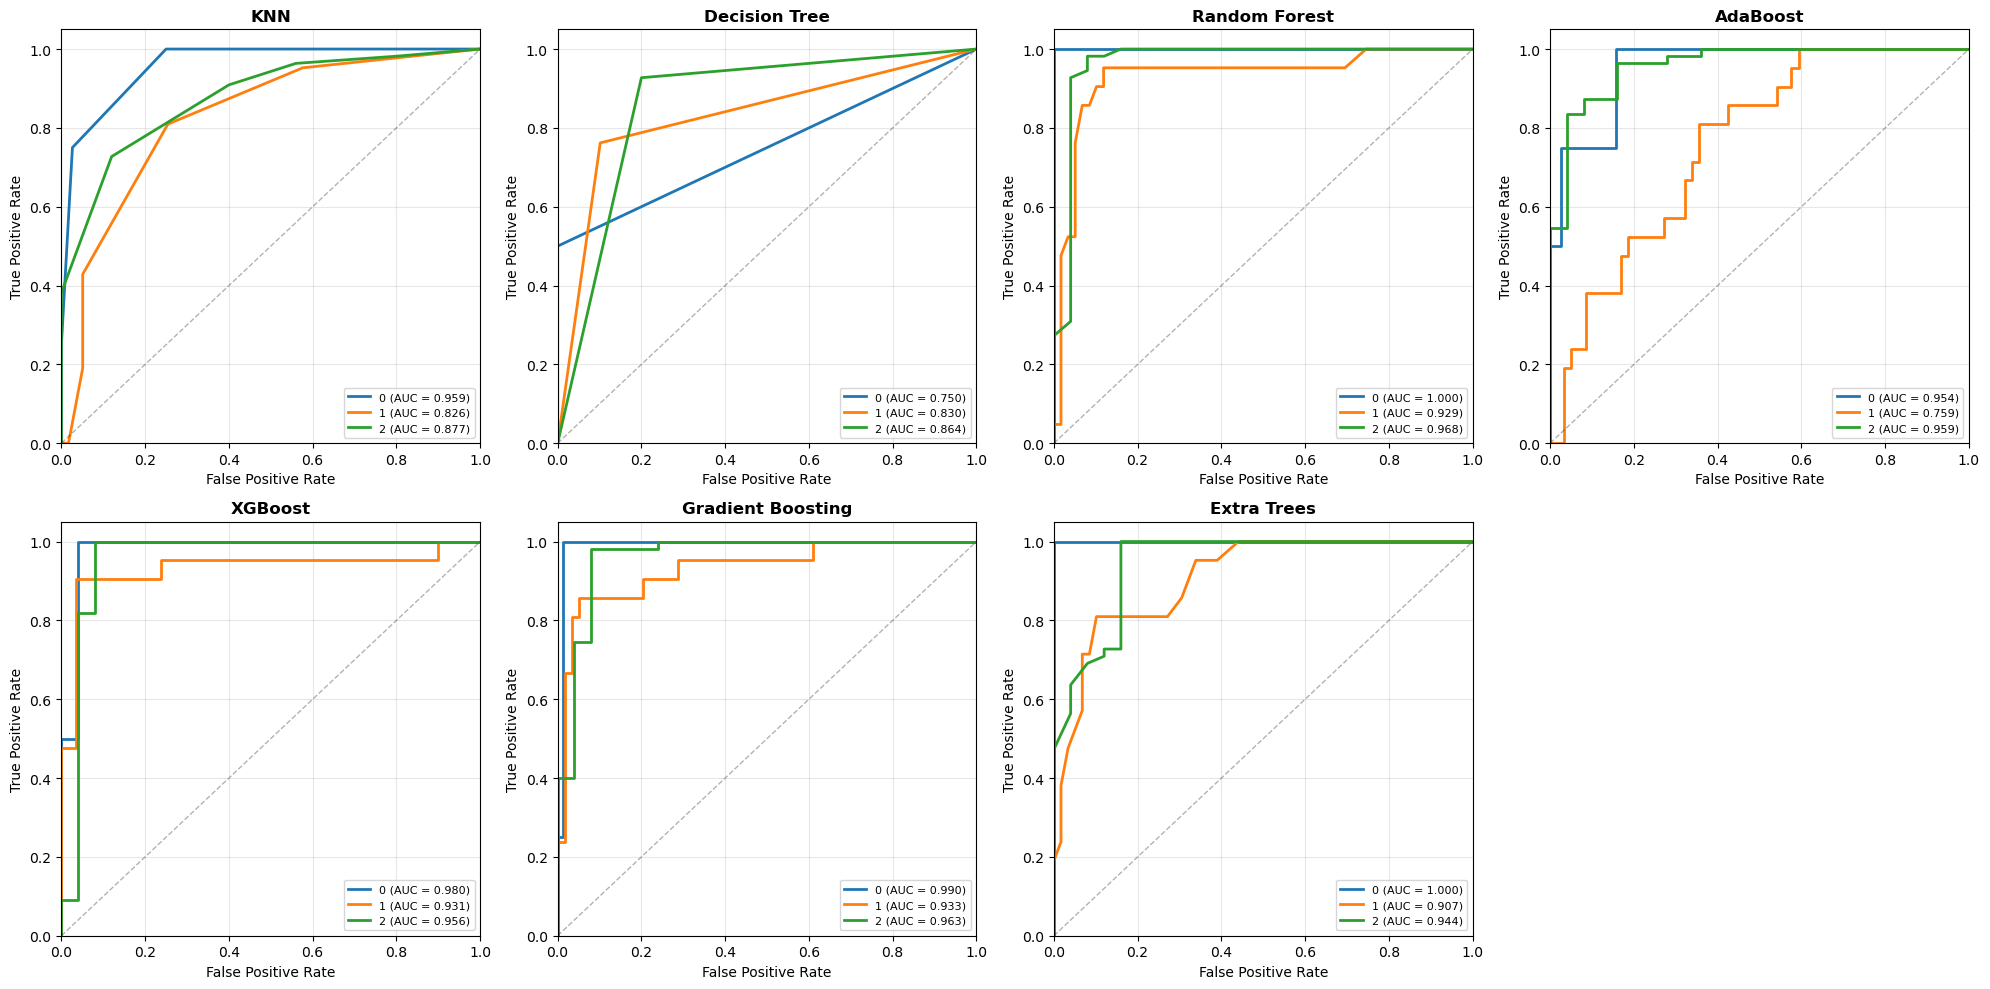

نمودارهای ROC با موفقیت ذخیره شد: roc_curves_severity.png

=== میانگین ROC-AUC برای هر مدل ===
KNN                 : 0.8875
Decision Tree       : 0.8146
Random Forest       : 0.9658
AdaBoost            : 0.8906
XGBoost             : 0.9560
Gradient Boosting   : 0.9620
Extra Trees         : 0.9505


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns




# بارگذاری مدل‌های آموزش‌دیده (فرض بر این است که قبلاً آموزش داده‌اند)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
import xgboost as xgb

# ایجاد مدل‌ها با تنظیمات مناسب (باید از مدل‌های آموزش‌دیده استفاده شود)
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, objective='multi:softprob', eval_metric='mlogloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

# آموزش مدل‌ها
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

# تبدیل برچسب‌ها به فرم باینری برای محاسبه ROC چندکلاسه
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# رسم نمودارهای ROC برای هر مدل
plt.style.use('default')
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()


# رمزگذاری متغیر هدف
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

class_names = le_target.classes_

for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    
    # پیش‌بینی احتمالات
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)
    
    # محاسبه ROC و AUC برای هر کلاس
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # رسم ROC برای هر کلاس
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i, color in zip(range(n_classes), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
    
    # خط قطری
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)

# حذف محور اضافی
fig.delaxes(axes[7])

plt.tight_layout()
plt.savefig('roc_curves_severity.png', dpi=300, bbox_inches='tight')
plt.show()

print("نمودارهای ROC با موفقیت ذخیره شد: roc_curves_severity.png")

# محاسبه میانگین AUC برای هر مدل
print("\n=== میانگین ROC-AUC برای هر مدل ===")
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)
    
    roc_auc_scores = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_scores.append(auc(fpr_i, tpr_i))
    
    mean_auc = np.mean(roc_auc_scores)
    print(f"{name:20s}: {mean_auc:.4f}")
